# Overview
This notebook tests the unconstrained MetaDoE PSO implementation against four standard optimization objectives in three dimensions and ten thousand dimensions.

# Optimization

In [ ]:
include("../../../src/MetaDoE.jl")
using .MetaDoE: Experiments, ConstraintEnforcement, Constraints, PSO, Objectives, Designs, Models, OptimizationRunner

## 3D

In [ ]:
N = 1
K = 3
bound = 10000
num_particles = 200
max_iters = 1000
max_stag = 200
tolerance = 1e-6

runner_params = PSO.runner_params(max_iters, max_stag, tolerance)
pso_params = PSO.create_hyperparams(num_particles)

In [ ]:
objectives = [Objectives.ackley, Objectives.rastrigin, Objectives.rosenbrock, Objectives.griewank]
enforcers = [ConstraintEnforcement.Penalty]
A, b = Constraints.hypercube(K, bound)

experiment = Experiments.create(N, K, Models.identity)
experiment = Experiments.with_linear_constraints(experiment, A, b)

Main.MetaDoE.Experiments.Experiment(Dict("1" => 1, "2" => 2, "3" => 3), Main.MetaDoE.ConstraintEnforcement.LinearConstraints([1.0 0.0 0.0; 0.0 1.0 0.0; … ; -0.0 -1.0 -0.0; -0.0 -0.0 -1.0], [10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0]), Main.MetaDoE.Models.var"#40#41"(), 1, 3)

In [22]:
OptimizationRunner.run_pso_experiments(
    experiment,
    objectives, 
    enforcers, 
    runner_params,
    OptimizationRunner.save_3d_results(prefix="data/3d_unconstrained")
)

Objective: ackley, Enforcer: Penalty
Objective: rosenbrock, Enforcer: Penalty
Objective: griewank, Enforcer: Penalty
Objective: rastrigin, Enforcer: Penalty
Best score: 0.0
Best score: 0.0
Best score: 0.08598545462404969
Best score: 4.440892098500626e-16


## 10kD

In [ ]:
N = 500
K = 20
bound = 10000
num_particles = 200
max_iters = 200
max_stag = 50
tolerance = 1e-6

runner_params = PSO.runner_params(max_iters, max_stag, tolerance)
pso_params = PSO.create_hyperparams(num_particles)

In [ ]:
objectives = [Objectives.ackley, Objectives.rastrigin, Objectives.rosenbrock, Objectives.griewank]
enforcers = [ConstraintEnforcement.Penalty]
A, b = Constraints.hypercube(K, bound)

experiment = Experiments.create(N, K, Models.identity)
experiment = Experiments.with_linear_constraints(experiment, A, b)

Main.MetaDoE.Experiments.Experiment(Dict("14" => 14, "4" => 4, "1" => 1, "12" => 12, "20" => 20, "2" => 2, "6" => 6, "7" => 7, "11" => 11, "13" => 13…), Main.MetaDoE.ConstraintEnforcement.LinearConstraints([1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; -0.0 -0.0 … -1.0 -0.0; -0.0 -0.0 … -0.0 -1.0], [10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0  …  10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0]), Main.MetaDoE.Models.var"#40#41"(), 500, 20)

In [ ]:
OptimizationRunner.run_pso_experiments(
    experiment,
    objectives, 
    enforcers, 
    runner_params,
    OptimizationRunner.save_3d_results(prefix="data/10kd_unconstrained")
)

# Visualization

## Convergence Plots

In [ ]:
from metadoe.visualization.convergence import plot_scores
import numpy as np
import itertools
from metadoe.visualization.phate import apply_phate, plot_phate

### 3D

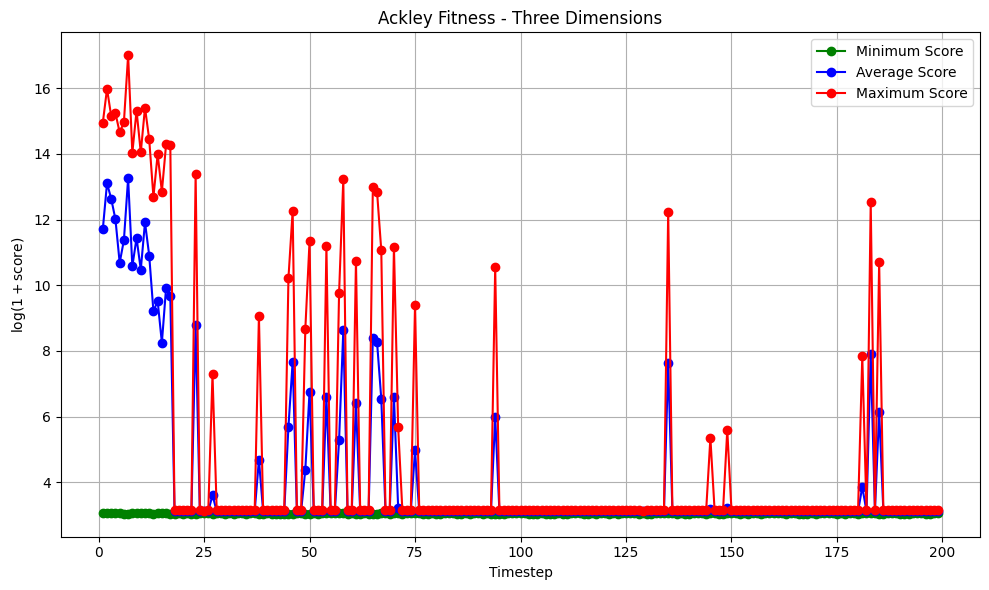

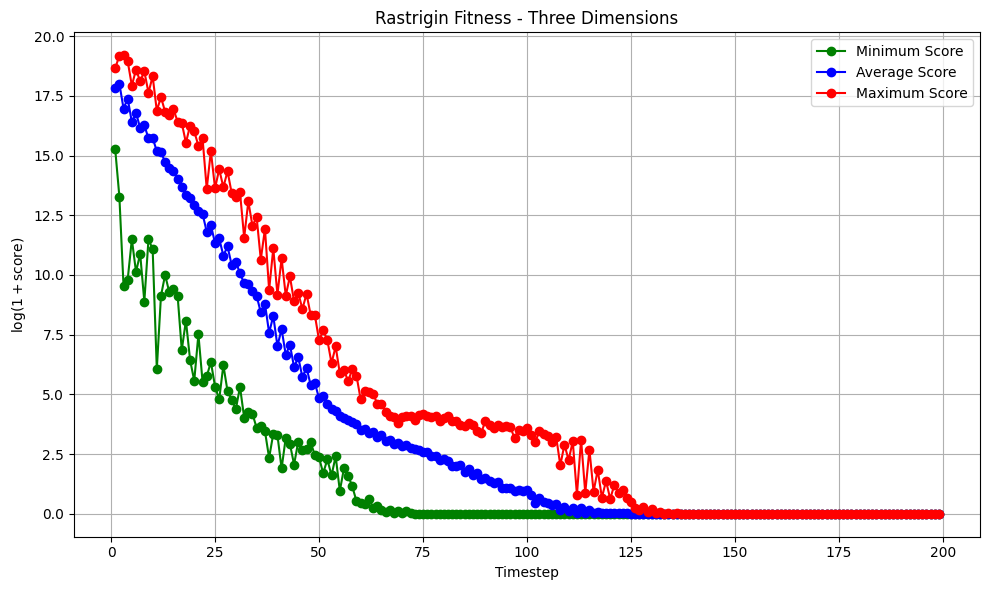

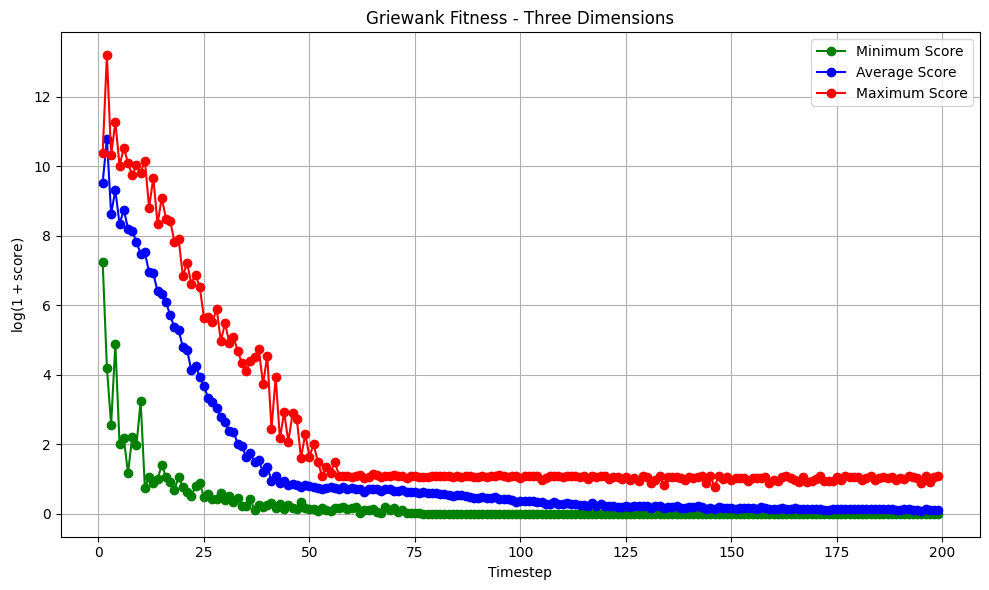

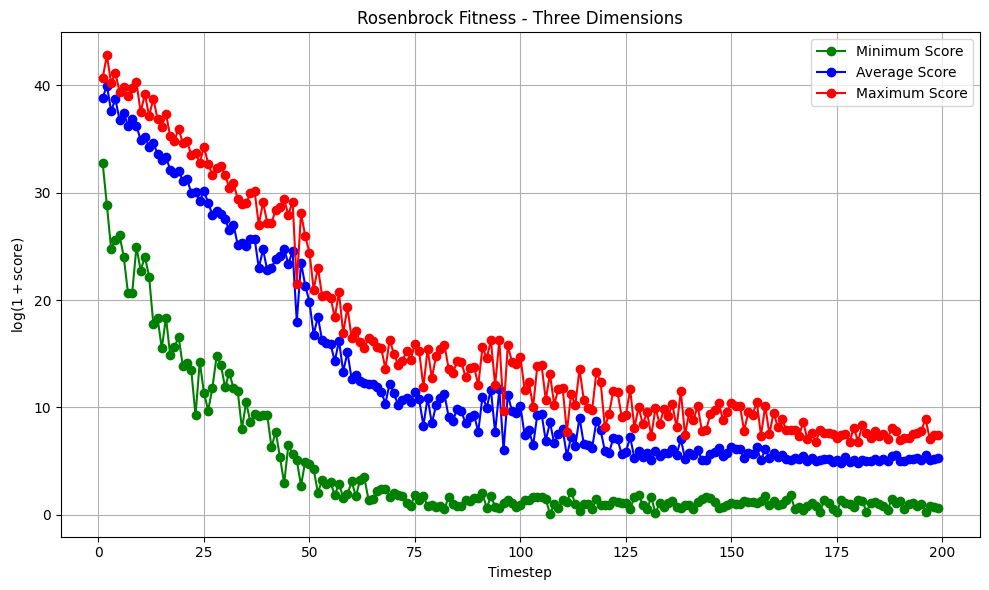

In [2]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['Penalty']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    data = np.load(f'data/3d_unconstrained_{objective}_{enforcer}.npy')
    scores = data['scores']
    plot_scores(scores, 1, 200, f"{objective.capitalize()} Fitness - Three Dimensions", f"plots/3d_unconstrained_{objective}_{enforcer}")

### 10kd

In [ ]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['Penalty']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    data = np.load(f'data/10kd_unconstrained_{objective}_{enforcer}.npy')
    scores = data['scores']
    plot_scores(scores, 1, 200, f"{objective.capitalize()} Fitness - Three Dimensions", f"plots/10kd_unconstrained_{objective}_{enforcer}")

## PHATE Plots

### 3D

Calculating PHATE...
  Running PHATE on 64900 observations and 3 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.35 seconds.
    Calculating affinities...


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 100 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 0.44 seconds.
  Calculated graph and diffusion operator in 0.81 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.45 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.60 seconds.
  Calculated landmark operator in 4.05 seconds.
  Calculating optimal t...
    Automatically selected t = 63
  Calculated optimal t in 0.48 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.79 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.06 seconds.
Calculated PHATE in 7.86 seconds.


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Calculating PHATE...
  Running PHATE on 30000 observations and 3 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.19 seconds.
    Calculating affinities...


...

/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Calculating PHATE...
  Running PHATE on 30800 observations and 3 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.15 seconds.
    Calculating affinities...


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 100 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 0.23 seconds.
  Calculated graph and diffusion operator in 0.38 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.65 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.14 seconds.
  Calculated landmark operator in 2.80 seconds.
  Calculating optimal t...
    Automatically selected t = 41
  Calculated optimal t in 0.49 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.60 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.18 seconds.
Calculated PHATE in 5.92 seconds.


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


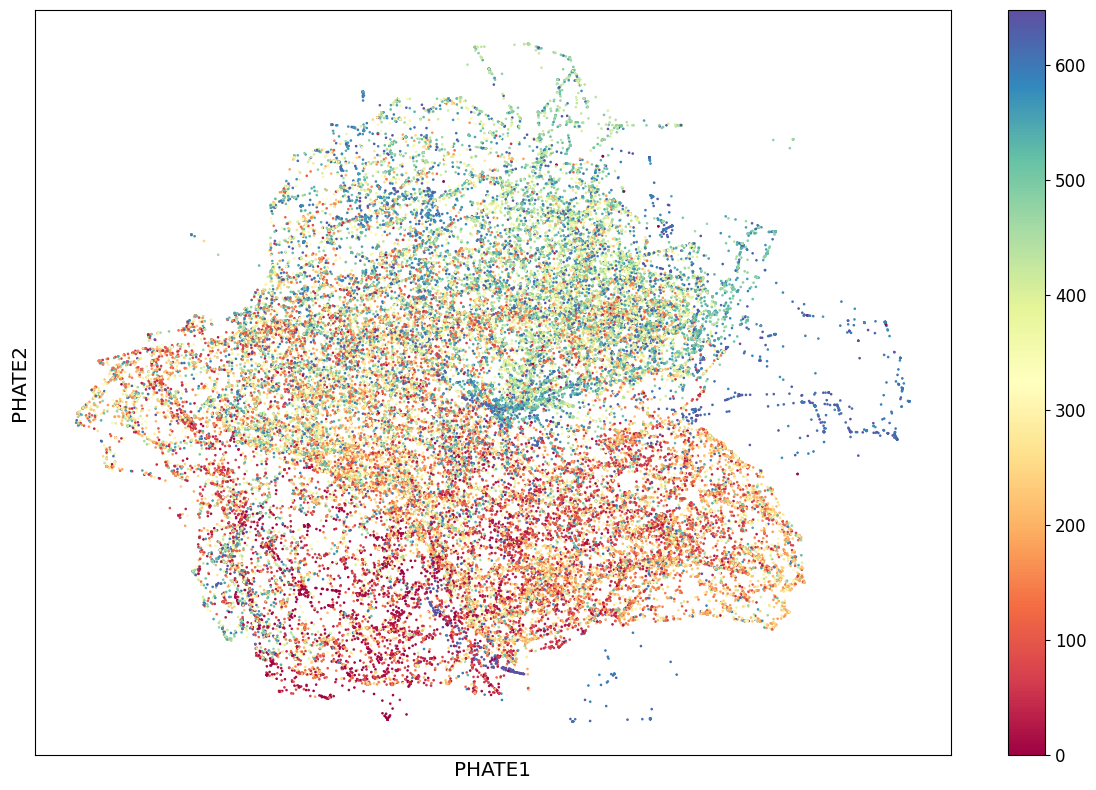

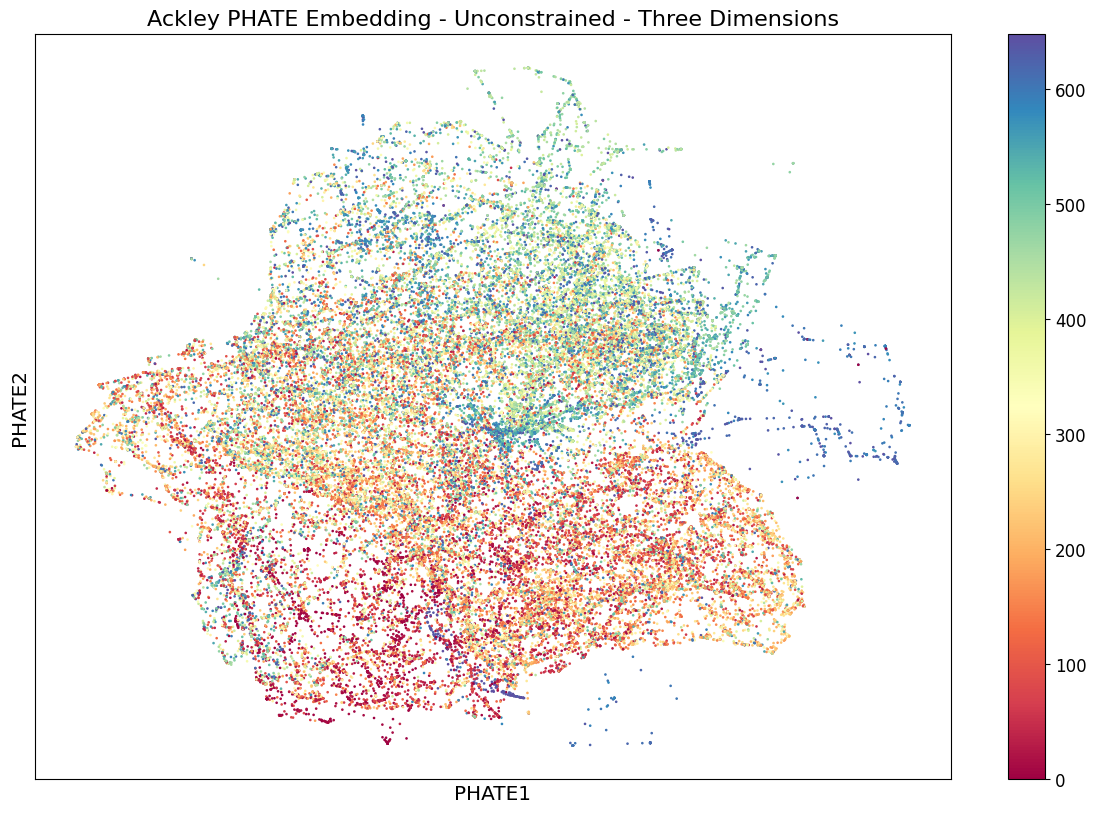

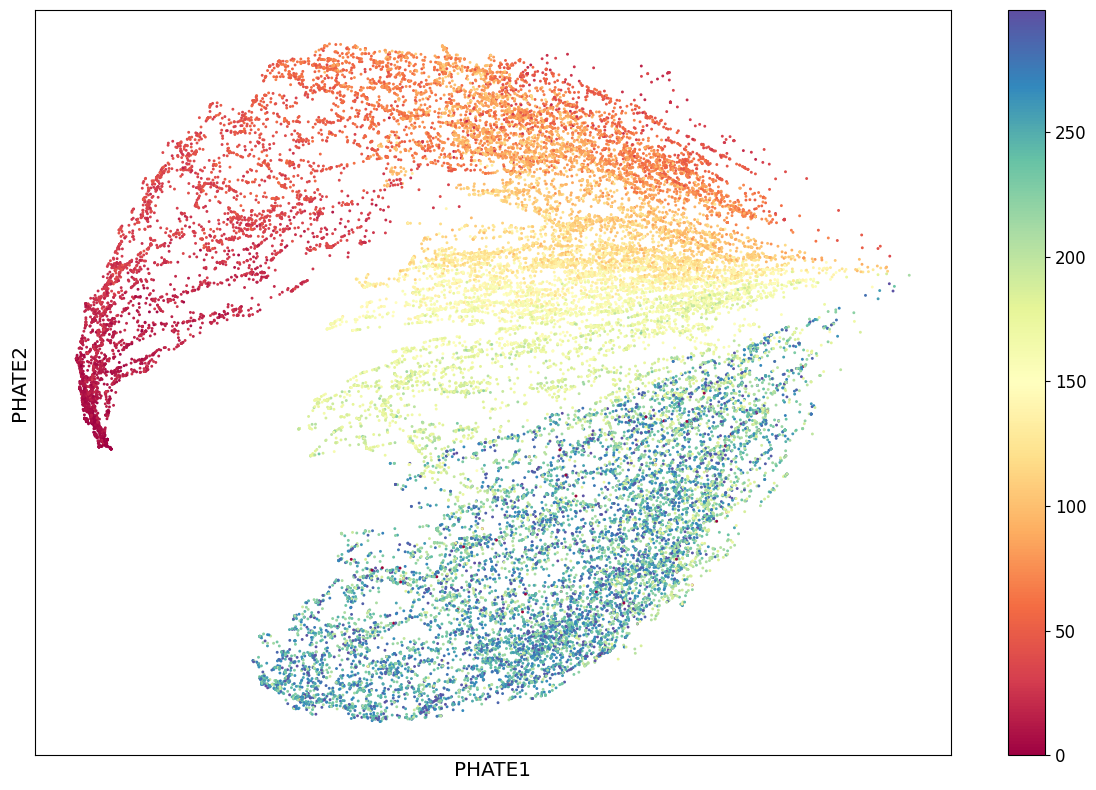

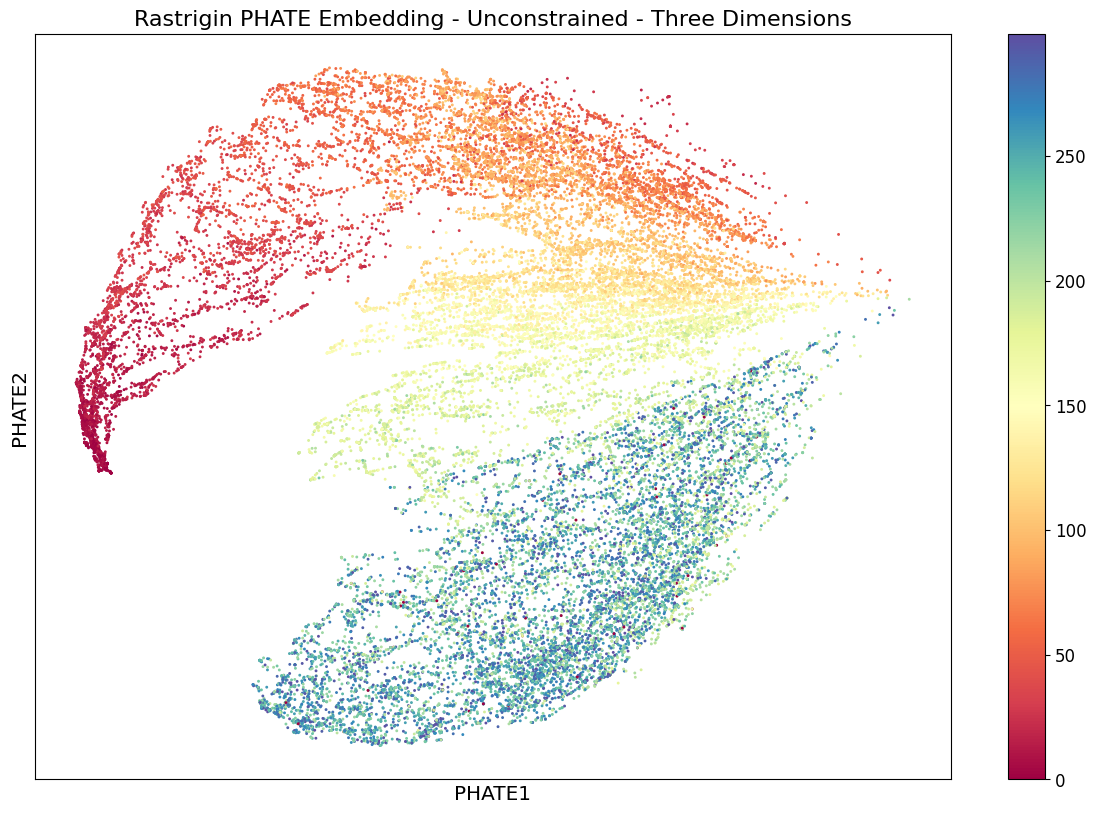

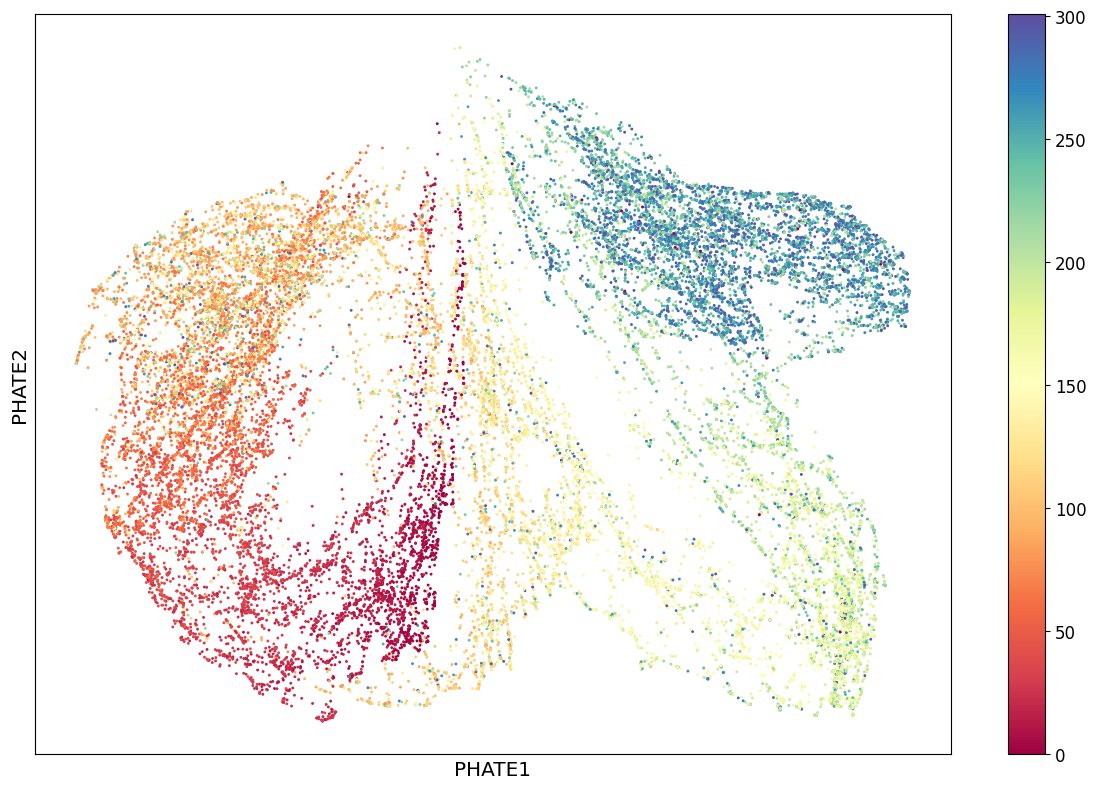

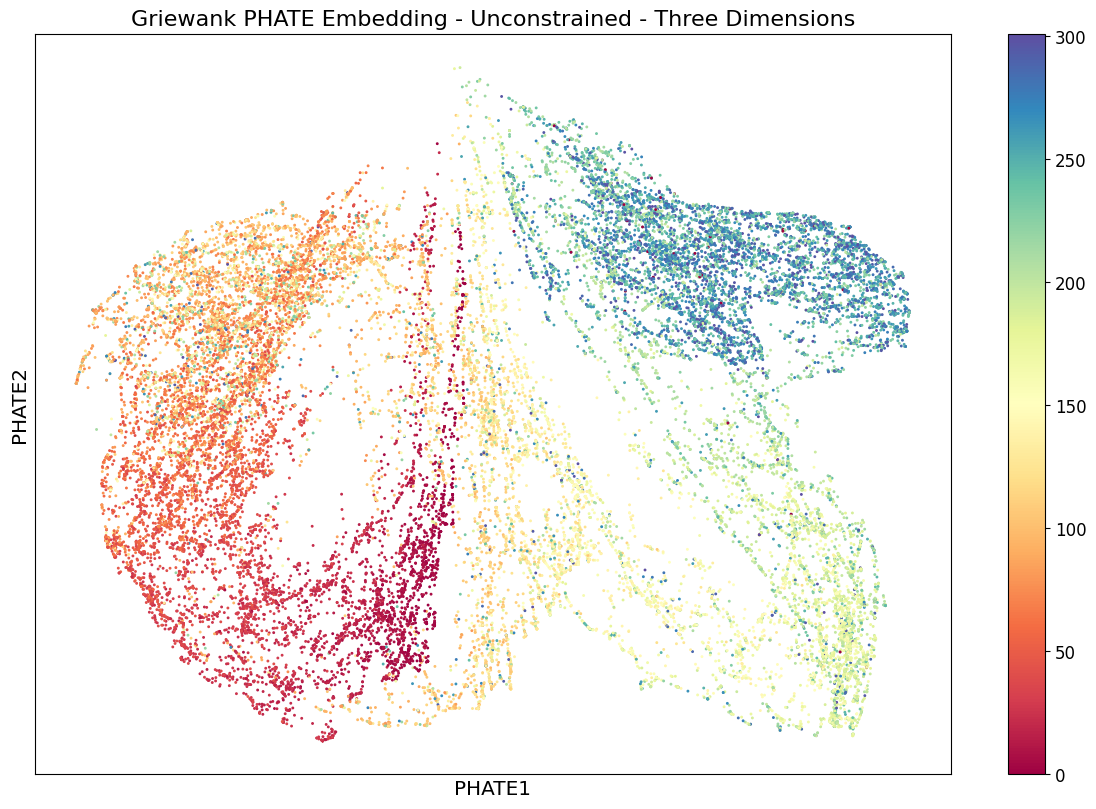

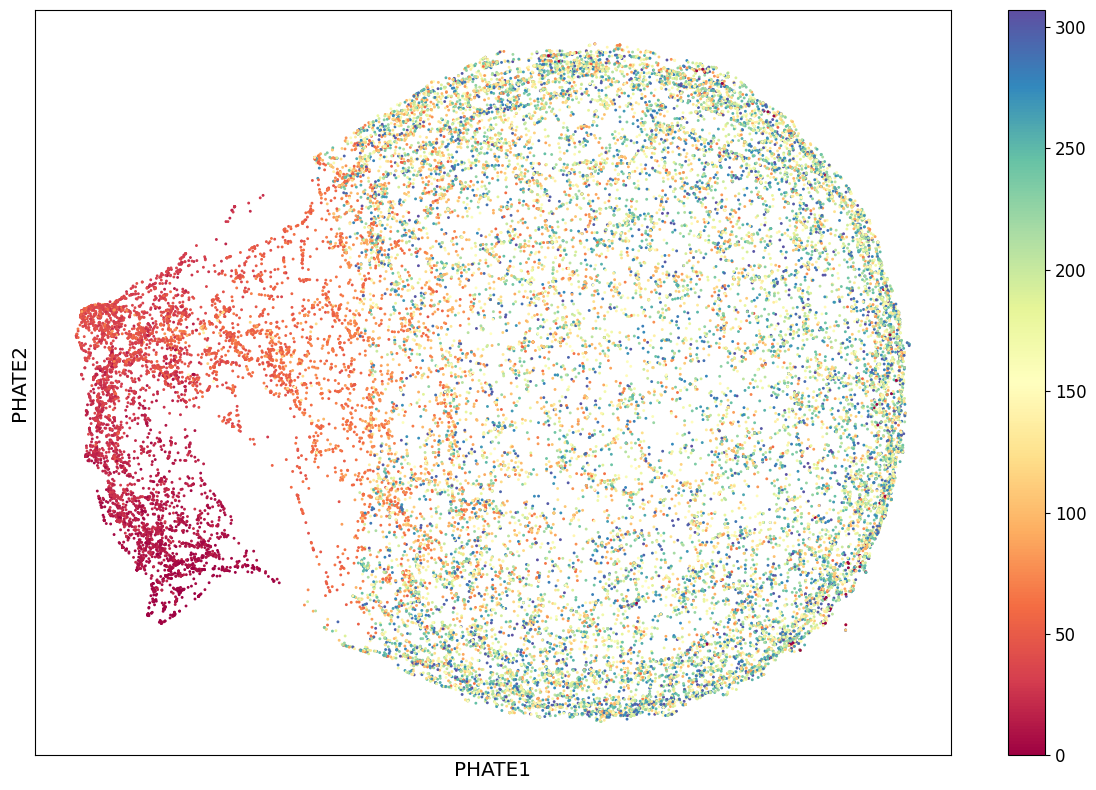

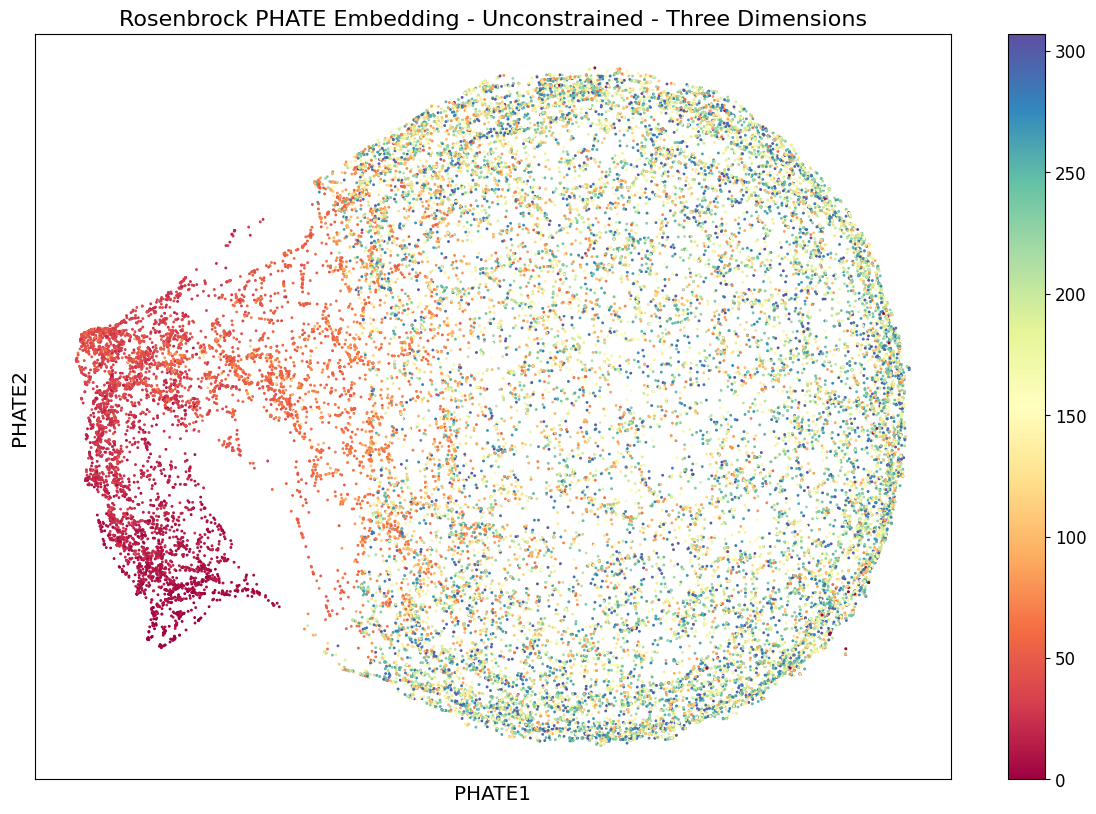

In [5]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['Penalty']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    # Load the data
    file_loc = f'data/3d_unconstrained_{objective}_{enforcer}.npy'

    # Apply phate
    Y_phate, time = apply_phate(file_loc)

    # Plot the PHATE embedding
    title = f"{objective.capitalize()} PHATE Embedding - Unconstrained - Three Dimensions"
    prefix = f"plots/3d_unconstrained_{objective}_{enforcer}"
    plot_phate(Y_phate, time, title, prefix)

### 10kD

In [ ]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['Penalty']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    # Load the data
    file_loc = f'data/10kd_unconstrained_{objective}_{enforcer}.npy'

    # Apply phate
    Y_phate, time = apply_phate(file_loc)

    # Plot the PHATE embedding
    title = f"{objective.capitalize()} PHATE Embedding - Unconstrained - 10k Dimensions"
    prefix = f"plots/10kd_unconstrained_{objective}_{enforcer}"
    plot_phate(Y_phate, time, title, prefix)